In [1]:
import numpy as np 
import tensorflow as tf
import cv2 as cv
import os
import mediapipe as mp 

In [2]:
from dataLoader import quick_load
# Path to your dataset
dataset_path = r"D:\GP\cleaned_landmarks_100words\cleaned_landmarks_100words"
    
# ============================================================
# METHOD 1: One-line loading (simplest)
# ============================================================
print("\n" + "="*60)
print("METHOD 1: One-line loading")
print("="*60)
cleaned_data, cleaned_labels = quick_load(dataset_path)
print(f"Loaded {len(cleaned_data)} samples")


METHOD 1: One-line loading
📦 Loading metadata from cache: D:\GP\cleaned_landmarks_100words\cleaned_landmarks_100words\.cache\metadata.pkl
✅ Loaded metadata for 2984 files


Loading data: 100%|██████████| 2984/2984 [00:46<00:00, 64.69it/s]

Loaded 2984 samples


In [3]:

dataset_path = r"D:\GP\before_cleaning_landmarks_100words\before_cleaning_landmarks_100words"
    
# ============================================================
# METHOD 1: One-line loading (simplest)
# ============================================================
print("\n" + "="*60)
print("METHOD 1: One-line loading")
print("="*60)
notcleaned_data, notcleaned_labels, = quick_load(dataset_path)
print(f"Loaded {len(notcleaned_data)} samples")


METHOD 1: One-line loading
📦 Loading metadata from cache: D:\GP\before_cleaning_landmarks_100words\before_cleaning_landmarks_100words\.cache\metadata.pkl
✅ Loaded metadata for 3283 files


Loading data: 100%|██████████| 3283/3283 [00:45<00:00, 71.59it/s] 

Loaded 3283 samples


In [4]:

# Method 3: Using numpy (if cleaned_data is a numpy array with object dtype)
if isinstance(cleaned_data, np.ndarray):
    max_frames = max([seq.shape[0] for seq in cleaned_data])
    print(f"Max frame length: {max_frames}")

Max frame length: 268


In [5]:
max_frames

268

📊 FRAME LENGTH STATISTICS
Total sequences: 2984
Max frames: 268
Min frames: 21
Mean frames: 79.42
Median frames: 74
Std frames: 30.99

📈 Frame Length Distribution (top 10 most common):
  60 frames: 64 sequences (2.1%)
  80 frames: 64 sequences (2.1%)
  77 frames: 58 sequences (1.9%)
  58 frames: 56 sequences (1.9%)
  61 frames: 55 sequences (1.8%)
  56 frames: 53 sequences (1.8%)
  74 frames: 51 sequences (1.7%)
  69 frames: 50 sequences (1.7%)
  62 frames: 50 sequences (1.7%)
  51 frames: 50 sequences (1.7%)


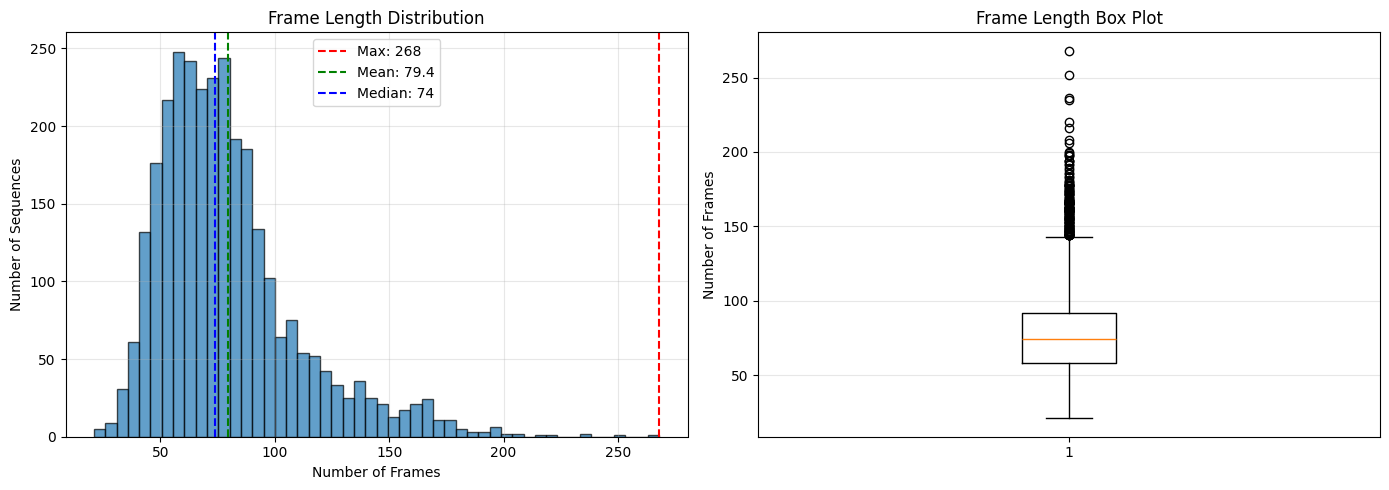


🚀 PROCESSING YOUR DATASET
Total sequences to process: 2984
Target max frames: 268


Processing sequences: 100%|██████████| 2984/2984 [00:29<00:00, 100.27it/s]



✅ PROCESSING COMPLETE!
Processed data shape: (2984, 268, 438)
Processed masks shape: (2984, 268)
Processed labels shape: (2984,)
Target frames: 268
Feature dimension: 438

📊 Mask Statistics:
  Mask min: 0.0
  Mask max: 1.0
  Mask mean: 0.150 (proportion of valid frames)

🔍 VERIFICATION - Sample Checks

Sample 0:
  Label: 1 DOLLAR
  Original frames: 36
  Padded frames: 268
  Mask coverage: 13.4%
  Data shape: (268, 438)
  Data range: [-6.132, 1.811]

Sample 1:
  Label: 1 DOLLAR
  Original frames: 39
  Padded frames: 268
  Mask coverage: 14.6%
  Data shape: (268, 438)
  Data range: [-4.056, 1.262]

Sample 2:
  Label: 1 DOLLAR
  Original frames: 36
  Padded frames: 268
  Mask coverage: 13.4%
  Data shape: (268, 438)
  Data range: [-5.576, 1.211]

Sample 3:
  Label: 1 DOLLAR
  Original frames: 44
  Padded frames: 268
  Mask coverage: 16.4%
  Data shape: (268, 438)
  Data range: [-5.202, 1.256]

Sample 4:
  Label: 1 DOLLAR
  Original frames: 40
  Padded frames: 268
  Mask coverage: 14.9%
 

In [6]:
# ============================================================
# JUPYTER NOTEBOOK FRIENDLY PREPROCESSING WITH PADDING AND MASK
# ============================================================

import numpy as np
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt

# ============================================================
# CONSTANTS
# ============================================================

POSE_LANDMARKS, POSE_VALS = 33, 4
HAND_LANDMARKS, HAND_VALS = 21, 3
FACE_LANDMARKS, FACE_VALS = 60, 3

POSE_SIZE = POSE_LANDMARKS * POSE_VALS          # 132
HAND_SIZE = HAND_LANDMARKS * HAND_VALS          # 63
FACE_SIZE = FACE_LANDMARKS * FACE_VALS          # 180
FEATURE_DIM = POSE_SIZE + FACE_SIZE + 2 * HAND_SIZE  # 438

# Legs to drop (knees->feet). Hips (23,24) are kept.
LEG_IDXS = list(range(25, 33))

# Critical joints we keep for transform even if visibility is low
CRITICAL_POSE_IDXS = {0, 11, 12, 13, 14, 15, 16, 23, 24}

# ============================================================
# GET MAX FRAME LENGTH FROM YOUR DATA
# ============================================================

# Assuming you already have cleaned_data and cleaned_labels
# cleaned_data = your sequences (list or numpy array)
# cleaned_labels = your labels

# Calculate max frames from your data
frame_lengths = [seq.shape[0] for seq in cleaned_data]
max_frames = max(frame_lengths)
min_frames = min(frame_lengths)
mean_frames = np.mean(frame_lengths)
median_frames = np.median(frame_lengths)

print("="*60)
print("📊 FRAME LENGTH STATISTICS")
print("="*60)
print(f"Total sequences: {len(cleaned_data)}")
print(f"Max frames: {max_frames}")
print(f"Min frames: {min_frames}")
print(f"Mean frames: {mean_frames:.2f}")
print(f"Median frames: {median_frames:.0f}")
print(f"Std frames: {np.std(frame_lengths):.2f}")

# Show distribution
from collections import Counter
length_dist = Counter(frame_lengths)
print(f"\n📈 Frame Length Distribution (top 10 most common):")
for length, count in sorted(length_dist.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {length} frames: {count} sequences ({count/len(cleaned_data)*100:.1f}%)")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(frame_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(max_frames, color='r', linestyle='--', label=f'Max: {max_frames}')
axes[0].axvline(mean_frames, color='g', linestyle='--', label=f'Mean: {mean_frames:.1f}')
axes[0].axvline(median_frames, color='b', linestyle='--', label=f'Median: {median_frames:.0f}')
axes[0].set_xlabel('Number of Frames')
axes[0].set_ylabel('Number of Sequences')
axes[0].set_title('Frame Length Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(frame_lengths, vert=True)
axes[1].set_ylabel('Number of Frames')
axes[1].set_title('Frame Length Box Plot')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================================
# GEOMETRY FUNCTIONS (Required for preprocessing)
# ============================================================

def in_unit_xy(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    return (np.isfinite(x) & np.isfinite(y) & (x >= 0.0) & (x <= 1.0) & (y >= 0.0) & (y <= 1.0))

def reasonable_xy(x: np.ndarray, y: np.ndarray, lo: float = -0.25, hi: float = 1.25) -> np.ndarray:
    return (np.isfinite(x) & np.isfinite(y) & (x >= lo) & (x <= hi) & (y >= lo) & (y <= hi))

def valid_points_xyz(arr: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    return np.any(np.abs(arr) > eps, axis=-1)

def is_valid_wrist(w: np.ndarray, eps: float = 1e-8) -> bool:
    return bool(np.isfinite(w).all() and np.any(np.abs(w) > eps))

def dist2(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.linalg.norm(a[:2] - b[:2]))

# ============================================================
# HAND FUNCTIONS
# ============================================================

def frame_valid_hand(hand_t: np.ndarray, min_pts: int = 8, eps: float = 1e-8) -> bool:
    nz = np.any(np.abs(hand_t) > eps, axis=1)
    return int(nz.sum()) >= int(min_pts)

def hand_centroid(hand_t: np.ndarray, eps: float = 1e-8):
    m = np.any(np.abs(hand_t) > eps, axis=1)
    if not np.any(m):
        return None
    return hand_t[m].mean(axis=0)

def fix_swap_and_gate_hands(lh, rh, lw, rw, min_pts=8, hand_wrist_max_dist=1.1, eps=1e-8):
    T = lh.shape[0]
    for t in range(T):
        l_ok = frame_valid_hand(lh[t], min_pts=min_pts, eps=eps)
        r_ok = frame_valid_hand(rh[t], min_pts=min_pts, eps=eps)
        wl_ok = is_valid_wrist(lw[t], eps=eps)
        wr_ok = is_valid_wrist(rw[t], eps=eps)
        cL = hand_centroid(lh[t], eps=eps) if l_ok else None
        cR = hand_centroid(rh[t], eps=eps) if r_ok else None

        if l_ok and r_ok and wl_ok and wr_ok and (cL is not None) and (cR is not None):
            d_ll = dist2(cL, lw[t])
            d_lr = dist2(cL, rw[t])
            d_rr = dist2(cR, rw[t])
            d_rl = dist2(cR, lw[t])
            if (d_lr + d_rl) + 1e-6 < (d_ll + d_rr):
                lh[t], rh[t] = rh[t].copy(), lh[t].copy()
                cL, cR = cR, cL

        if wl_ok and l_ok and (cL is not None):
            if dist2(cL, lw[t]) > hand_wrist_max_dist:
                lh[t] = 0.0
        if wr_ok and r_ok and (cR is not None):
            if dist2(cR, rw[t]) > hand_wrist_max_dist:
                rh[t] = 0.0

def fill_hand_gaps_wrist_relative_tiered(hand, wrist, small_gap=6, medium_gap=15, min_pts=8, rel_change_thresh=0.7, eps=1e-8):
    T = hand.shape[0]
    valid = np.array([frame_valid_hand(hand[t], min_pts=min_pts, eps=eps) for t in range(T)], dtype=bool)
    idx = np.where(valid)[0]
    if idx.size == 0:
        return

    def set_from_rel(t: int, rel: np.ndarray):
        if is_valid_wrist(wrist[t], eps=eps):
            hand[t] = rel + wrist[t]

    for a, b in zip(idx[:-1], idx[1:]):
        gap = int(b - a - 1)
        if gap <= 0:
            continue
        if gap > medium_gap:
            continue

        if not (is_valid_wrist(wrist[a], eps=eps) and is_valid_wrist(wrist[b], eps=eps)):
            if gap <= small_gap:
                for t in range(a + 1, b):
                    hand[t] = hand[a]
            continue

        rel_a = hand[a] - wrist[a]
        rel_b = hand[b] - wrist[b]

        if gap > small_gap:
            for t in range(a + 1, b):
                set_from_rel(t, rel_a)
            continue

        delta = np.linalg.norm(rel_a - rel_b, axis=1)
        delta = delta[np.isfinite(delta)]
        rel_delta = float(np.median(delta)) if delta.size else 999.0

        if rel_delta <= rel_change_thresh:
            for t in range(a + 1, b):
                alpha = (t - a) / (b - a)
                rel = (1.0 - alpha) * rel_a + alpha * rel_b
                set_from_rel(t, rel)
        else:
            for t in range(a + 1, b):
                set_from_rel(t, rel_a)

def trim_edge_filler_frames(seq: np.ndarray, margin: int = 2, eps: float = 1e-8) -> np.ndarray:
    if seq.ndim != 2 or seq.shape[1] != FEATURE_DIM:
        return seq
    T = int(seq.shape[0])
    if T == 0:
        return seq
    lh = seq[:, POSE_SIZE + FACE_SIZE:POSE_SIZE + FACE_SIZE + HAND_SIZE].reshape(T, HAND_LANDMARKS, HAND_VALS)
    rh = seq[:, POSE_SIZE + FACE_SIZE + HAND_SIZE:].reshape(T, HAND_LANDMARKS, HAND_VALS)
    l_present = np.array([frame_valid_hand(lh[t], min_pts=1, eps=eps) for t in range(T)], dtype=bool)
    r_present = np.array([frame_valid_hand(rh[t], min_pts=1, eps=eps) for t in range(T)], dtype=bool)
    active = l_present | r_present
    idx = np.where(active)[0]
    if idx.size == 0:
        return seq
    start = max(0, int(idx[0]) - int(margin))
    end = min(T - 1, int(idx[-1]) + int(margin))
    if start == 0 and end == T - 1:
        return seq
    return seq[start:end + 1]

# ============================================================
# NORMALIZATION FUNCTIONS
# ============================================================

def compute_global_root(pose_xyz: np.ndarray, vis: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    def collect_mid(i1: int, i2: int):
        m = (vis[:, i1] > 0.0) & (vis[:, i2] > 0.0)
        m = m & valid_points_xyz(pose_xyz[:, i1, :], eps) & valid_points_xyz(pose_xyz[:, i2, :], eps)
        if not np.any(m):
            return None
        return (pose_xyz[m, i1, :] + pose_xyz[m, i2, :]) / 2.0

    mid_hip = collect_mid(23, 24)
    if mid_hip is not None:
        return mid_hip.mean(axis=0)
    mid_sh = collect_mid(11, 12)
    if mid_sh is not None:
        return mid_sh.mean(axis=0)
    m_nose = (vis[:, 0] > 0.0) & valid_points_xyz(pose_xyz[:, 0, :], eps)
    if np.any(m_nose):
        return pose_xyz[m_nose, 0, :].mean(axis=0)
    m_all = (vis > 0.0) & valid_points_xyz(pose_xyz, eps)
    if np.any(m_all):
        return pose_xyz[m_all].mean(axis=0)
    return np.zeros(3, dtype=np.float32)

def compute_global_scale(pose_xyz: np.ndarray, vis: np.ndarray, root: np.ndarray, eps: float = 1e-6) -> float:
    def collect_dist(i1: int, i2: int):
        m = (vis[:, i1] > 0.0) & (vis[:, i2] > 0.0)
        m = m & valid_points_xyz(pose_xyz[:, i1, :]) & valid_points_xyz(pose_xyz[:, i2, :])
        if not np.any(m):
            return None
        d = np.linalg.norm(pose_xyz[m, i1, :] - pose_xyz[m, i2, :], axis=1)
        d = d[d > eps]
        return d if d.size > 0 else None

    d_sh = collect_dist(11, 12)
    if d_sh is not None:
        return float(d_sh.mean())
    d_hip = collect_dist(23, 24)
    if d_hip is not None:
        return float(d_hip.mean())
    m_all = (vis > 0.0) & valid_points_xyz(pose_xyz)
    if np.any(m_all):
        d = np.linalg.norm(pose_xyz[m_all] - root[None, :], axis=1)
        d = d[d > eps]
        if d.size > 0:
            return float(d.mean())
    return 1.0

# ============================================================
# SMOOTHING FUNCTIONS (Optional)
# ============================================================

def _alpha(cutoff_hz: float, dt: float) -> float:
    cutoff_hz = float(max(cutoff_hz, 1e-6))
    tau = 1.0 / (2.0 * np.pi * cutoff_hz)
    return float(1.0 / (1.0 + tau / dt))

def one_euro_filter_series(x: np.ndarray, valid: np.ndarray, fps: float, min_cutoff: float, beta: float, d_cutoff: float) -> np.ndarray:
    T, D = x.shape
    out = np.zeros_like(x, dtype=np.float32)
    dt = 1.0 / float(max(fps, 1e-6))
    x_prev = np.zeros(D, dtype=np.float32)
    x_hat_prev = np.zeros(D, dtype=np.float32)
    dx_hat_prev = np.zeros(D, dtype=np.float32)
    has_prev = False

    for t in range(T):
        if not bool(valid[t]):
            has_prev = False
            continue
        xt = x[t].astype(np.float32, copy=False)
        if not has_prev:
            out[t] = xt
            x_prev = xt
            x_hat_prev = xt
            dx_hat_prev[:] = 0.0
            has_prev = True
            continue
        dx = (xt - x_prev) / dt
        a_d = _alpha(d_cutoff, dt)
        dx_hat = a_d * dx + (1.0 - a_d) * dx_hat_prev
        cutoff = float(min_cutoff + beta * np.linalg.norm(dx_hat))
        a = _alpha(cutoff, dt)
        x_hat = a * xt + (1.0 - a) * x_hat_prev
        out[t] = x_hat
        x_prev = xt
        x_hat_prev = x_hat
        dx_hat_prev = dx_hat
    return out

def smooth_points_over_time(pts: np.ndarray, eps: float, fps: float, min_cutoff: float, beta: float, d_cutoff: float) -> None:
    T, N, _ = pts.shape
    for i in range(N):
        x = pts[:, i, :]
        valid = valid_points_xyz(x, eps=eps) & np.isfinite(x).all(axis=1)
        if not np.any(valid):
            continue
        pts[:, i, :] = one_euro_filter_series(x, valid=valid, fps=fps, min_cutoff=min_cutoff, beta=beta, d_cutoff=d_cutoff)

# ============================================================
# MAIN PREPROCESSING FUNCTION
# ============================================================

def preprocess_single_sequence(
    seq: np.ndarray,
    pose_vis_thresh: float = 0.1,
    keep_legs: bool = False,
    fix_swap: bool = True,
    fill_hands: bool = True,
    small_gap: int = 6,
    medium_gap: int = 15,
    min_hand_pts: int = 8,
    hand_wrist_max_dist: float = 1.1,
    rel_change_thresh: float = 0.7,
    smooth: bool = False,
    smooth_fps: float = 20.0,
    smooth_pose: bool = True,
    smooth_hands: bool = True,
    smooth_face: bool = False,
    pose_min_cutoff: float = 1.5,
    pose_beta: float = 0.6,
    hand_min_cutoff: float = 3.0,
    hand_beta: float = 0.8,
    face_min_cutoff: float = 2.0,
    face_beta: float = 0.6,
    d_cutoff: float = 1.0,
    eps: float = 1e-8,
) -> np.ndarray:
    """Preprocess a single sequence without padding/mask generation."""
    y = seq.astype(np.float32, copy=True)
    if y.ndim != 2 or y.shape[1] != FEATURE_DIM:
        raise ValueError(f"Expected shape (T,{FEATURE_DIM}), got {y.shape}")

    y = trim_edge_filler_frames(y, margin=2, eps=eps)

    pose = y[:, :POSE_SIZE].reshape(-1, POSE_LANDMARKS, POSE_VALS)
    face = y[:, POSE_SIZE:POSE_SIZE + FACE_SIZE].reshape(-1, FACE_LANDMARKS, FACE_VALS)
    lh = y[:, POSE_SIZE + FACE_SIZE:POSE_SIZE + FACE_SIZE + HAND_SIZE].reshape(-1, HAND_LANDMARKS, HAND_VALS)
    rh = y[:, POSE_SIZE + FACE_SIZE + HAND_SIZE:].reshape(-1, HAND_LANDMARKS, HAND_VALS)

    # Pose cleaning
    px, py, pz, pv = pose[:, :, 0], pose[:, :, 1], pose[:, :, 2], pose[:, :, 3]
    finite_pose = np.isfinite(pz) & np.isfinite(pv)
    pose_in_strict = in_unit_xy(px, py) & finite_pose
    pose_in_relaxed = reasonable_xy(px, py) & finite_pose
    critical_mask = np.zeros((pose.shape[0], POSE_LANDMARKS), dtype=bool)
    for i in CRITICAL_POSE_IDXS:
        critical_mask[:, i] = True
    pose_keep_for_transform = (pv >= pose_vis_thresh) & pose_in_strict
    pose_keep_for_transform = pose_keep_for_transform | (critical_mask & pose_in_relaxed)
    pose_keep_visible = (pv >= pose_vis_thresh) & pose_in_strict
    bad_xyz = ~pose_keep_for_transform
    pose[bad_xyz, :3] = 0.0
    pose[~pose_keep_visible, 3] = 0.0
    if not keep_legs:
        pose[:, LEG_IDXS, :3] = 0.0
        pose[:, LEG_IDXS, 3] = 0.0

    # Face cleaning
    fx, fy, fz = face[:, :, 0], face[:, :, 1], face[:, :, 2]
    face_in = reasonable_xy(fx, fy) & np.isfinite(fz)
    face[~face_in, :3] = 0.0

    # Hands cleaning
    lx, ly, lz = lh[:, :, 0], lh[:, :, 1], lh[:, :, 2]
    lh_in = reasonable_xy(lx, ly) & np.isfinite(lz)
    lh[~lh_in, :3] = 0.0
    rx, ry, rz = rh[:, :, 0], rh[:, :, 1], rh[:, :, 2]
    rh_in = reasonable_xy(rx, ry) & np.isfinite(rz)
    rh[~rh_in, :3] = 0.0

    # Global normalization
    pose_xyz = pose[:, :, :3]
    vis = pose[:, :, 3]
    root = compute_global_root(pose_xyz, vis, eps=eps)
    scale = compute_global_scale(pose_xyz, vis, root)
    pose_valid_for_transform = pose_keep_for_transform & valid_points_xyz(pose_xyz, eps=eps)
    pose_xyz[pose_valid_for_transform] = (pose_xyz[pose_valid_for_transform] - root) / scale
    pose[:, :, :3] = pose_xyz
    for arr in (face, lh, rh):
        m = valid_points_xyz(arr, eps=eps)
        arr[m] = (arr[m] - root) / scale

    # Wrists
    lw = pose_xyz[:, 15, :].copy()
    rw = pose_xyz[:, 16, :].copy()

    if fix_swap:
        fix_swap_and_gate_hands(lh, rh, lw, rw, min_pts=min_hand_pts, hand_wrist_max_dist=hand_wrist_max_dist, eps=eps)
    if fill_hands:
        fill_hand_gaps_wrist_relative_tiered(lh, lw, small_gap=small_gap, medium_gap=medium_gap, min_pts=min_hand_pts, rel_change_thresh=rel_change_thresh, eps=eps)
        fill_hand_gaps_wrist_relative_tiered(rh, rw, small_gap=small_gap, medium_gap=medium_gap, min_pts=min_hand_pts, rel_change_thresh=rel_change_thresh, eps=eps)

    # Optional smoothing
    if smooth:
        if smooth_pose:
            smooth_points_over_time(pose[:, :, :3], eps=eps, fps=smooth_fps, min_cutoff=pose_min_cutoff, beta=pose_beta, d_cutoff=d_cutoff)
        if smooth_hands:
            smooth_points_over_time(lh, eps=eps, fps=smooth_fps, min_cutoff=hand_min_cutoff, beta=hand_beta, d_cutoff=d_cutoff)
            smooth_points_over_time(rh, eps=eps, fps=smooth_fps, min_cutoff=hand_min_cutoff, beta=hand_beta, d_cutoff=d_cutoff)
        if smooth_face:
            smooth_points_over_time(face, eps=eps, fps=smooth_fps, min_cutoff=face_min_cutoff, beta=face_beta, d_cutoff=d_cutoff)

    # Reconstruct
    out = np.empty_like(y, dtype=np.float32)
    out[:, :POSE_SIZE] = pose.reshape(-1, POSE_SIZE)
    out[:, POSE_SIZE:POSE_SIZE + FACE_SIZE] = face.reshape(-1, FACE_SIZE)
    out[:, POSE_SIZE + FACE_SIZE:POSE_SIZE + FACE_SIZE + HAND_SIZE] = lh.reshape(-1, HAND_SIZE)
    out[:, POSE_SIZE + FACE_SIZE + HAND_SIZE:] = rh.reshape(-1, HAND_SIZE)
    return out

# ============================================================
# PADDING AND MASK FUNCTIONS
# ============================================================

def pad_to_max_frames_simple(landmarks: np.ndarray, max_frames: int) -> tuple:
    """
    Pad landmarks to max_frames and create mask.
    
    Args:
        landmarks: numpy array of shape (T, FEATURE_DIM)
        max_frames: Target number of frames
    
    Returns:
        tuple: (padded_landmarks, mask)
    """
    current_frames = landmarks.shape[0]
    
    if current_frames >= max_frames:
        return landmarks[:max_frames], np.ones(max_frames, dtype=np.float32)
    
    pad_length = max_frames - current_frames
    pad = np.zeros((pad_length, FEATURE_DIM), dtype=landmarks.dtype)
    padded_landmarks = np.vstack([landmarks, pad])
    
    mask = np.zeros(max_frames, dtype=np.float32)
    mask[:current_frames] = 1.0
    
    return padded_landmarks, mask

# ============================================================
# PROCESS YOUR ENTIRE DATASET
# ============================================================

print("\n" + "="*60)
print("🚀 PROCESSING YOUR DATASET")
print("="*60)
print(f"Total sequences to process: {len(cleaned_data)}")
print(f"Target max frames: {max_frames}")
print("="*60)

# Process all sequences
processed_data = []
processed_masks = []
processed_labels = []

# You can disable preprocessing by setting preprocess=False if data is already preprocessed
preprocess = True  # Set to False if your data is already preprocessed

for i in tqdm(range(len(cleaned_data)), desc="Processing sequences"):
    try:
        seq = cleaned_data[i]
        label = cleaned_labels[i]
        
        # Apply preprocessing if needed
        if preprocess:
            seq = preprocess_single_sequence(seq)
        
        # Pad to max frames and create mask
        padded_seq, mask = pad_to_max_frames_simple(seq, max_frames)
        
        processed_data.append(padded_seq)
        processed_masks.append(mask)
        processed_labels.append(label)
        
    except Exception as e:
        print(f"Error processing sequence {i}: {e}")
        continue

# Convert to numpy arrays
processed_data = np.array(processed_data, dtype=np.float32)
processed_masks = np.array(processed_masks, dtype=np.float32)
processed_labels = np.array(processed_labels)

print("\n" + "="*60)
print("✅ PROCESSING COMPLETE!")
print("="*60)
print(f"Processed data shape: {processed_data.shape}")
print(f"Processed masks shape: {processed_masks.shape}")
print(f"Processed labels shape: {processed_labels.shape}")
print(f"Target frames: {max_frames}")
print(f"Feature dimension: {FEATURE_DIM}")

# Verify mask values
print(f"\n📊 Mask Statistics:")
print(f"  Mask min: {processed_masks.min()}")
print(f"  Mask max: {processed_masks.max()}")
print(f"  Mask mean: {processed_masks.mean():.3f} (proportion of valid frames)")

# ============================================================
# VERIFICATION - Check a few samples
# ============================================================

print("\n" + "="*60)
print("🔍 VERIFICATION - Sample Checks")
print("="*60)

for i in range(min(5, len(processed_data))):
    seq = processed_data[i]
    mask = processed_masks[i]
    label = processed_labels[i]
    
    original_frames = int(mask.sum())
    padded_frames = len(seq)
    
    print(f"\nSample {i}:")
    print(f"  Label: {label}")
    print(f"  Original frames: {original_frames}")
    print(f"  Padded frames: {padded_frames}")
    print(f"  Mask coverage: {original_frames/padded_frames*100:.1f}%")
    print(f"  Data shape: {seq.shape}")
    print(f"  Data range: [{seq.min():.3f}, {seq.max():.3f}]")

# ============================================================
# SAVE PROCESSED DATA (Optional)
# ============================================================

# Uncomment to save to disk
# output_dir = Path("./padded_data")
# output_dir.mkdir(parents=True, exist_ok=True)
# 
# np.save(output_dir / "processed_data.npy", processed_data)
# np.save(output_dir / "processed_masks.npy", processed_masks)
# np.save(output_dir / "processed_labels.npy", processed_labels)
# 
# print(f"\n💾 Saved processed data to {output_dir}")

print("\n" + "="*60)
print("✅ DONE! Ready for training with masks")
print("="*60)

In [7]:
# Preprocess your data
processed_masks.shape

(2984, 268)

In [8]:
processed_masks[390]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

📊 RENDERING PROCESSED DATA
Total videos: 2984
Frames per video: 268
Feature dim: 438

🎬 Rendering video 0: 1 DOLLAR
Rendering 268 frames for label: 1 DOLLAR

📊 Mask Coverage Information:
  Video 0 (1 DOLLAR): 13.4% valid frames
  Video 1 (1 DOLLAR): 14.6% valid frames
  Video 2 (1 DOLLAR): 13.4% valid frames
  Video 3 (1 DOLLAR): 16.4% valid frames
  Video 4 (1 DOLLAR): 14.9% valid frames

✅ Ready to render! Use the functions above with your processed_data.


Using device: cpu
📊 Data Information:
   Feature dimension: 438
   Target frames: 268
   Total samples: 2984

🏷️ Label encoding complete: 105 classes

📊 Class distribution:
   Total classes: 105
   Min samples per class: 2
   Max samples per class: 61
   Mean samples per class: 28.42

⚠️ Classes with <3 samples (1 classes):
   AUTISM: 2 sample(s)

✅ All classes have at least 2 samples

📊 Creating train/val/test splits...
✅ Stratified split successful

📊 Split sizes:
   Train: 2387 samples
   Validation: 298 samples
   Test: 299 samples

📊 Class distribution in splits:
   Train classes: 105
   Val classes: 104
   Test classes: 104

✅ DataLoaders created:
   Train batches: 150
   Val batches: 19
   Test batches: 19

📐 Large dataset detected. Using larger model

📐 MODEL ARCHITECTURE:
   Input: 438 features x 268 frames
   CNN Channels: [64, 128, 256]
   LSTM Hidden: 512, Layers: 2
   Total parameters: 12,148,246
   Parameters per sample: 5089.3
   ⚠️ WARNING: Model may overfit! Consider r

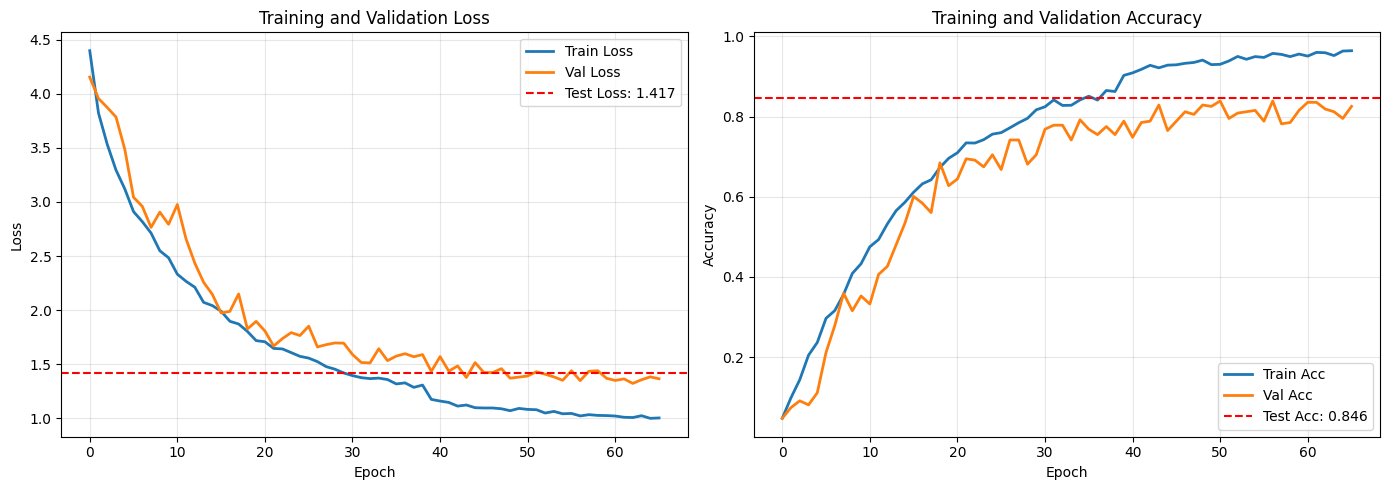

📊 Training plots saved to 'training_results.png'

✅ TRAINING COMPLETE!


In [13]:
# ============================================================
# APPLY CNN + BiLSTM + ATTENTION MODEL TO YOUR PROCESSED DATA (FIXED)
# ============================================================

import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
import pickle
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

# ============================================================
# CONFIGURATION - ADJUST FOR YOUR DATA
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# Get dimensions from your data
FEATURE_DIM = processed_data.shape[2]  # Should be 438
TARGET_FRAMES = processed_data.shape[1]  # Max frames from your data

print(f"📊 Data Information:")
print(f"   Feature dimension: {FEATURE_DIM}")
print(f"   Target frames: {TARGET_FRAMES}")
print(f"   Total samples: {len(processed_data)}")

# ============================================================
# ENCODE LABELS AND CHECK CLASS DISTRIBUTION
# ============================================================

# Encode labels
le = LabelEncoder()
all_labels_encoded = le.fit_transform(processed_labels)
num_classes = len(le.classes_)

print(f"\n🏷️ Label encoding complete: {num_classes} classes")

# Check class distribution
label_counts = Counter(processed_labels)
print(f"\n📊 Class distribution:")
print(f"   Total classes: {num_classes}")
print(f"   Min samples per class: {min(label_counts.values())}")
print(f"   Max samples per class: {max(label_counts.values())}")
print(f"   Mean samples per class: {np.mean(list(label_counts.values())):.2f}")

# Find classes with very few samples
rare_classes = {label: count for label, count in label_counts.items() if count < 3}
if rare_classes:
    print(f"\n⚠️ Classes with <3 samples ({len(rare_classes)} classes):")
    for label, count in list(rare_classes.items())[:10]:
        print(f"   {label}: {count} sample(s)")

# ============================================================
# FILTER RARE CLASSES (OPTIONAL)
# ============================================================

MIN_SAMPLES_PER_CLASS = 2

if min(label_counts.values()) < MIN_SAMPLES_PER_CLASS:
    print(f"\n⚠️ Filtering classes with < {MIN_SAMPLES_PER_CLASS} samples...")
    
    keep_classes = [label for label, count in label_counts.items() if count >= MIN_SAMPLES_PER_CLASS]
    keep_mask = [label in keep_classes for label in processed_labels]
    
    processed_data_filtered = processed_data[keep_mask]
    processed_masks_filtered = processed_masks[keep_mask]
    processed_labels_filtered = processed_labels[keep_mask]
    
    le = LabelEncoder()
    all_labels_encoded = le.fit_transform(processed_labels_filtered)
    num_classes = len(le.classes_)
    
    print(f"   Removed {len(processed_labels) - len(processed_labels_filtered)} samples")
    print(f"   Removed {len(label_counts) - num_classes} rare classes")
    print(f"   Remaining classes: {num_classes}")
    print(f"   Remaining samples: {len(processed_labels_filtered)}")
    
    processed_data = processed_data_filtered
    processed_masks = processed_masks_filtered
    processed_labels = processed_labels_filtered
else:
    print(f"\n✅ All classes have at least {MIN_SAMPLES_PER_CLASS} samples")

# ============================================================
# CREATE STRATIFIED SPLIT (WITH FALLBACK)
# ============================================================

print(f"\n📊 Creating train/val/test splits...")

try:
    X_train, X_temp, y_train, y_temp, m_train, m_temp = train_test_split(
        processed_data, all_labels_encoded, processed_masks,
        test_size=0.2, stratify=all_labels_encoded, random_state=42
    )
    
    X_val, X_test, y_val, y_test, m_val, m_test = train_test_split(
        X_temp, y_temp, m_temp,
        test_size=0.5, stratify=y_temp, random_state=42
    )
    
    print(f"✅ Stratified split successful")
    
except ValueError as e:
    print(f"⚠️ Stratified split failed: {e}")
    print("   Falling back to non-stratified split...")
    
    X_train, X_temp, y_train, y_temp, m_train, m_temp = train_test_split(
        processed_data, all_labels_encoded, processed_masks,
        test_size=0.3, random_state=42
    )
    
    X_val, X_test, y_val, y_test, m_val, m_test = train_test_split(
        X_temp, y_temp, m_temp,
        test_size=0.5, random_state=42
    )
    
    print(f"✅ Non-stratified split completed")

print(f"\n📊 Split sizes:")
print(f"   Train: {len(X_train)} samples")
print(f"   Validation: {len(X_val)} samples")
print(f"   Test: {len(X_test)} samples")

print(f"\n📊 Class distribution in splits:")
print(f"   Train classes: {len(np.unique(y_train))}")
print(f"   Val classes: {len(np.unique(y_val))}")
print(f"   Test classes: {len(np.unique(y_test))}")

# ============================================================
# DATASET CLASS
# ============================================================

class ASLDataset(Dataset):
    def __init__(self, data, masks, labels, augment=False):
        self.data = torch.from_numpy(data).float()
        self.masks = torch.from_numpy(masks).float()
        self.labels = torch.from_numpy(labels).long()
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.data[idx]
        m = self.masks[idx]
        y = self.labels[idx]
        
        if self.augment:
            if torch.rand(1) > 0.5:
                noise = torch.randn_like(x) * 0.01
                x = x + noise
            
            if torch.rand(1) > 0.5:
                scale = torch.rand(1) * 0.2 + 0.9
                x = x * scale
        
        return x, m, y

# ============================================================
# CREATE DATALOADERS
# ============================================================

BATCH_SIZE = min(16, len(X_train))
NUM_WORKERS = 0

train_dataset = ASLDataset(X_train, m_train, y_train, augment=True)
val_dataset = ASLDataset(X_val, m_val, y_val, augment=False)
test_dataset = ASLDataset(X_test, m_test, y_test, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"\n✅ DataLoaders created:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

# ============================================================
# CNN + BiLSTM + ATTENTION MODEL (FIXED MASK HANDLING)
# ============================================================

class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        
        self.residual = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        
    def forward(self, x):
        residual = self.residual(x)
        
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x + residual)
        x = self.dropout(x)
        
        return x


class CNNBiLSTMAttention(nn.Module):
    def __init__(self, input_dim=438, num_classes=105, 
                 cnn_channels=[64, 128, 256], 
                 lstm_hidden=256, 
                 lstm_layers=2,
                 dropout=0.4):
        super().__init__()
        
        # Input normalization
        self.input_bn = nn.BatchNorm1d(input_dim)
        
        # CNN layers for feature extraction
        self.cnn_layers = nn.ModuleList()
        in_ch = input_dim
        self.pooling_info = []  # Track pooling to adjust mask
        
        for i, out_ch in enumerate(cnn_channels):
            self.cnn_layers.append(CNNBlock(in_ch, out_ch, kernel_size=3, dropout=dropout))
            if i < len(cnn_channels) - 1:
                self.cnn_layers.append(nn.MaxPool1d(2))
                self.pooling_info.append(2)  # Record pooling factor
            in_ch = out_ch
        
        self.cnn_output_dim = cnn_channels[-1]
        
        # Calculate the temporal dimension after CNN
        self.temporal_reduction = 2 ** len(self.pooling_info) if self.pooling_info else 1
        
        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=self.cnn_output_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0
        )
        
        # Attention mechanism
        self.attention_weights = nn.Sequential(
            nn.Linear(lstm_hidden * 2, lstm_hidden),
            nn.Tanh(),
            nn.Linear(lstm_hidden, 1)
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, lstm_hidden * 2),
            nn.BatchNorm1d(lstm_hidden * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden * 2, lstm_hidden),
            nn.BatchNorm1d(lstm_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, num_classes)
        )
        
    def adjust_mask(self, mask):
        """
        Adjust mask through pooling layers
        Mask is downsampled by factor of 2 for each pooling layer
        """
        if mask is None:
            return None
        
        # mask shape: (batch, frames)
        # After maxpool1d, we need to downsample the mask
        for _ in self.pooling_info:
            # Use max pooling to downsample mask
            # We want to keep the mask as 1 if any frame in the window is valid
            mask = mask.unsqueeze(1)  # (batch, 1, frames)
            mask = F.max_pool1d(mask, kernel_size=2, stride=2)
            mask = mask.squeeze(1)  # (batch, frames/2)
        
        return mask
    
    def forward(self, x, mask=None):
        """
        Args:
            x: (batch, frames, features)
            mask: (batch, frames) - optional mask for padding (1 for valid, 0 for padding)
        """
        # Transpose for CNN: (batch, features, frames)
        x = x.transpose(1, 2)
        
        # Apply input normalization
        x = self.input_bn(x)
        
        # Apply CNN layers
        for layer in self.cnn_layers:
            x = layer(x)
        
        # Adjust mask through pooling layers
        if mask is not None:
            mask = self.adjust_mask(mask)
        
        # Transpose for LSTM: (batch, frames, features)
        x = x.transpose(1, 2)
        
        # Apply LSTM
        lstm_out, (hidden, cell) = self.lstm(x)  # lstm_out: (batch, frames, hidden*2)
        
        # Apply attention with adjusted mask
        attention_scores = self.attention_weights(lstm_out)  # (batch, frames, 1)
        
        if mask is not None:
            # Expand mask to match attention_scores dimensions
            mask = mask.unsqueeze(-1)  # (batch, frames, 1)
            # Ensure mask has same temporal length as attention_scores
            if mask.size(1) != attention_scores.size(1):
                # Interpolate mask if sizes don't match
                mask = F.interpolate(mask.transpose(1, 2), size=attention_scores.size(1), mode='nearest')
                mask = mask.transpose(1, 2)
            attention_scores = attention_scores.masked_fill(mask == 0, -1e9)
        
        attention_weights = F.softmax(attention_scores, dim=1)  # (batch, frames, 1)
        
        # Weighted sum
        context = torch.sum(attention_weights * lstm_out, dim=1)  # (batch, hidden*2)
        
        # Classify
        output = self.classifier(context)
        
        return output


# Adjust model size based on dataset
if len(X_train) < 50:
    cnn_channels = [32, 64]
    lstm_hidden = 128
    lstm_layers = 1
    dropout = 0.5
    print(f"\n📐 Small dataset detected. Using smaller model")
elif len(X_train) < 200:
    cnn_channels = [64, 128]
    lstm_hidden = 256
    lstm_layers = 2
    dropout = 0.4
    print(f"\n📐 Medium dataset detected. Using medium model")
else:
    cnn_channels = [64, 128, 256]
    lstm_hidden = 512
    lstm_layers = 2
    dropout = 0.3
    print(f"\n📐 Large dataset detected. Using larger model")

# Initialize model
model = CNNBiLSTMAttention(
    input_dim=FEATURE_DIM,
    num_classes=num_classes,
    cnn_channels=cnn_channels,
    lstm_hidden=lstm_hidden,
    lstm_layers=lstm_layers,
    dropout=dropout
).to(DEVICE)

# Calculate model size
total_params = sum(p.numel() for p in model.parameters())
params_per_sample = total_params / len(X_train)

print(f"\n📐 MODEL ARCHITECTURE:")
print(f"   Input: {FEATURE_DIM} features x {TARGET_FRAMES} frames")
print(f"   CNN Channels: {cnn_channels}")
print(f"   LSTM Hidden: {lstm_hidden}, Layers: {lstm_layers}")
print(f"   Total parameters: {total_params:,}")
print(f"   Parameters per sample: {params_per_sample:.1f}")

if params_per_sample > 500:
    print(f"   ⚠️ WARNING: Model may overfit! Consider reducing size.")
elif params_per_sample < 50:
    print(f"   ✅ Model size appropriate for dataset")
else:
    print(f"   ⚠️ Model size acceptable")

# ============================================================
# LOSS FUNCTION AND OPTIMIZER
# ============================================================

if num_classes > 1:
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
    print(f"\n⚖️ Class weights computed for {num_classes} classes")
else:
    class_weights = None

class SmoothCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight
        
    def forward(self, logits, targets):
        n_classes = logits.size(1)
        if n_classes == 1:
            return F.binary_cross_entropy_with_logits(logits.squeeze(), targets.float())
        
        with torch.no_grad():
            true_dist = torch.zeros_like(logits)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        
        log_probs = F.log_softmax(logits, dim=1)
        
        if self.weight is not None:
            weight = self.weight[targets]
            loss = -(true_dist * log_probs).sum(dim=1) * weight
        else:
            loss = -(true_dist * log_probs).sum(dim=1)
            
        return loss.mean()

# Training configuration
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 100
PATIENCE = 15
GRAD_CLIP = 1.0
LABEL_SMOOTH = 0.1

criterion = SmoothCrossEntropy(smoothing=LABEL_SMOOTH, weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# ============================================================
# TRAINING FUNCTIONS
# ============================================================

def train_one_epoch(loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for x, m, y in loader:
        x, m, y = x.to(DEVICE), m.to(DEVICE), y.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(x, m)
        loss = criterion(outputs, y)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        
        total_loss += loss.item() * y.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(y).sum().item()
        total += y.size(0)
    
    return total_loss / total, correct / total

def evaluate(loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, m, y in loader:
            x, m, y = x.to(DEVICE), m.to(DEVICE), y.to(DEVICE)
            outputs = model(x, m)
            loss = criterion(outputs, y)
            
            total_loss += loss.item() * y.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(y).sum().item()
            total += y.size(0)
    
    return total_loss / total, correct / total

# ============================================================
# TRAINING LOOP
# ============================================================

print("\n" + "="*60)
print("🚀 STARTING TRAINING (CNN + BiLSTM + Attention)")
print("="*60)
print(f"   Device: {DEVICE}")
print(f"   Training samples: {len(X_train)}")
print(f"   Validation samples: {len(X_val)}")
print(f"   Test samples: {len(X_test)}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Learning rate: {LR}")
print(f"   Epochs: {EPOCHS}")
print("="*60)

best_val_acc = 0
patience_counter = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(train_loader)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    val_loss, val_acc = evaluate(val_loader)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1:03d}/{EPOCHS} | "
          f"LR: {current_lr:.2e} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'train_loss': train_loss,
            'model_config': {
                'input_dim': FEATURE_DIM,
                'num_classes': num_classes,
                'cnn_channels': cnn_channels,
                'lstm_hidden': lstm_hidden,
                'lstm_layers': lstm_layers,
                'dropout': dropout
            }
        }, 'best_cnn_lstm_attention_model.pth')
        print(f"  ✅ Best model saved! (Val Acc: {val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early stopping at epoch {epoch+1}")
            break

# ============================================================
# FINAL EVALUATION
# ============================================================

print("\n" + "="*60)
print("📊 FINAL EVALUATION")
print("="*60)

checkpoint = torch.load('best_cnn_lstm_attention_model.pth', map_location=torch.device(DEVICE))
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"   Validation Accuracy: {checkpoint['val_acc']:.4f}")

test_loss, test_acc = evaluate(test_loader)
print(f"\n🎯 TEST SET RESULTS:")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# ============================================================
# SAVE RESULTS
# ============================================================

np.save('label_encoder.npy', le.classes_)

history = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accs': train_accs,
    'val_accs': val_accs,
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
    'test_loss': test_loss,
    'num_classes': num_classes,
    'target_frames': TARGET_FRAMES,
    'feature_dim': FEATURE_DIM,
    'model_params': total_params,
    'model_config': {
        'cnn_channels': cnn_channels,
        'lstm_hidden': lstm_hidden,
        'lstm_layers': lstm_layers,
        'dropout': dropout
    }
}

with open('training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

print(f"\n💾 Saved files:")
print(f"   Model: best_cnn_lstm_attention_model.pth")
print(f"   Label encoder: label_encoder.npy")
print(f"   Training history: training_history.pkl")

# ============================================================
# PLOT RESULTS
# ============================================================

try:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(train_losses, label='Train Loss', linewidth=2)
    axes[0].plot(val_losses, label='Val Loss', linewidth=2)
    axes[0].axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.3f}')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(train_accs, label='Train Acc', linewidth=2)
    axes[1].plot(val_accs, label='Val Acc', linewidth=2)
    axes[1].axhline(y=test_acc, color='r', linestyle='--', label=f'Test Acc: {test_acc:.3f}')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_results.png', dpi=150)
    plt.show()
    print("📊 Training plots saved to 'training_results.png'")
    
except Exception as e:
    print(f"⚠️ Could not plot: {e}")

print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print("="*60)